# Laboratorio 6: libreria sintetica
# libreria SDV
# fecha 05 de junio
# Elizabeth Vega Pacheco

In [18]:
#importamos librerias basicas
import pandas as pd
import numpy as np
import random

In [19]:
#importamos librerias para datos sinteticos 
import sdv
import sdmetrics

In [20]:
import warnings
warnings.filterwarnings('ignore')

In [21]:
#importamos sublibrerias para la generacion da datos
from sdv.metadata import SingleTableMetadata
from sdv.single_table import GaussianCopulaSynthesizer 

In [22]:
#importamos sublibrerias para la evaluacion de los datos 
from sdmetrics.reports.single_table import QualityReport


In [23]:
print("SDV: ", sdv.__version__)
print("SDMetrics:", sdmetrics.__version__)

SDV:  1.37.0
SDMetrics: 0.28.0


In [24]:
#crear una tabla de datos REAL como base para 
# la generacion de datos sinteticos
dfClientes=pd.DataFrame(
    {
        "cliente_id": [1,2,3,4,5,6,7,8,9,10],
        "edad":[17,18,19,25,32,42,70,28,23,22],
        "ingreso_mensual":[17,18,19,25,32,42,70,28,23,22],
        "ciudad":["potrero","atoyac","ciuchapa","cordoba","cuitlahuac","orizaba","paraje","yanga","tierra blanca","calcahualco"],
    }
    
)

In [25]:
dfClientes

,cliente_id,edad,ingreso_mensual,ciudad
0,1,17,17,potrero
1,2,18,18,atoyac
2,3,19,19,ciuchapa
3,4,25,25,cordoba
4,5,32,32,cuitlahuac
5,6,42,42,orizaba
6,7,70,70,paraje
7,8,28,28,yanga
8,9,23,23,tierra blanca
9,10,22,22,calcahualco


In [26]:
##obtener los metadata

In [27]:
##creamos una instancia de singletablemetadata
metadata = SingleTableMetadata()

In [28]:
metadata.detect_from_dataframe(
    data = dfClientes
)

In [29]:
metadata.to_dict()

{'primary_key': 'cliente_id',
 'METADATA_SPEC_VERSION': 'SINGLE_TABLE_V1',
 'columns': {'cliente_id': {'sdtype': 'id'},
  'edad': {'sdtype': 'numerical'},
  'ingreso_mensual': {'sdtype': 'numerical'},
  'ciudad': {'sdtype': 'categorical'}}}

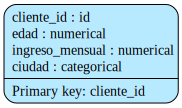

In [30]:
metadata.visualize()

In [31]:
#entrenar el modelo de datos sinteticos

In [38]:
# Le pasamos los metadatos
sintetizador = GaussianCopulaSynthesizer(
    metadata
)

In [39]:
#entrenamos el sintetizador con los datos reales
sintetizador.fit(
    dfClientes
)

In [40]:
#generamos los datos sinteticos
dfClientes_falsos= sintetizador.sample(
    num_rows=200
)

In [41]:
dfClientes_falsos

,cliente_id,edad,ingreso_mensual,ciudad
0,16169768,33,33,tierra blanca
1,4918803,21,21,cordoba
2,1900081,19,19,orizaba
3,531516,18,18,cordoba
4,10211768,36,36,yanga
...,...,...,...,...
195,1577423,18,18,cuitlahuac
196,2804584,18,18,atoyac
197,10420935,39,39,orizaba
198,16659394,34,34,cuitlahuac


In [42]:
dfClientes_falsos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   cliente_id       200 non-null    int64 
 1   edad             200 non-null    int64 
 2   ingreso_mensual  200 non-null    int64 
 3   ciudad           200 non-null    object
dtypes: int64(3), object(1)
memory usage: 6.4+ KB


In [43]:
dfClientes.describe()

,cliente_id,edad,ingreso_mensual
count,10.00000,10.000000,10.000000
mean,5.50000,29.600000,29.600000
std,3.02765,16.063762,16.063762
min,1.00000,17.000000,17.000000
25%,3.25000,19.750000,19.750000
50%,5.50000,24.000000,24.000000
75%,7.75000,31.000000,31.000000
max,10.00000,70.000000,70.000000


In [44]:
dfClientes_falsos.describe()

,cliente_id,edad,ingreso_mensual
count,2.000000e+02,200.000000,200.000000
mean,8.765887e+06,26.365000,26.365000
std,4.707538e+06,13.166952,13.166952
min,4.660500e+04,18.000000,18.000000
25%,5.085226e+06,18.000000,18.000000
50%,9.212590e+06,19.000000,19.000000
75%,1.279456e+07,31.000000,31.000000
max,1.677377e+07,70.000000,70.000000



## Evaluamos los datos para validad
## Conclusiones
1.parecido entre las columnas (columns shapes score)
2. parecido entre las relaciones de las columnas (evaluating column per trends)
3. evaluacion del dataset general

In [45]:
#evaluamos la calidad de los datos
#creamos una instancia de qualityreport
reporte = QualityReport()

In [ ]:
reporte.generate(
    real_data=dfClientes,
    synthetic_data=dfClientes_falsos,
    metdata= metadata.to dict()
)